# Fichier principal
# fusion de tous les fichiers.ipynb avec le fichier application_train.ipynb

In [51]:
import os
import re
import numpy as np
import pandas as pd
import gc
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve, auc, make_scorer, average_precision_score, make_scorer
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold, cross_val_score, cross_val_predict,cross_validate, TunedThresholdClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE

import catboost
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, cv, Pool
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import mlflow.catboost
import optuna
import shap
from mlflow.models.signature import infer_signature


print(" Imports terminés")

 Imports terminés


In [2]:
print(catboost.__version__) # pour vérifier si __sklearn_tags__ s'implemente

1.2.10


# optimisation de la RAM

In [3]:
def reduce_mem_usage(df, verbose=True):
    """Réduit l'usage mémoire en convertissant les types de données"""
    start_mem = df.memory_usage().sum() / 1024**2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float32)
    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Mémoire réduite de {start_mem:.2f} MB à {end_mem:.2f} MB ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    
    return df

# bureau et bureau_balance

In [4]:
with open("bureau_agg.pkl", "rb") as f:
    bureau_agg = pickle.load(f)

gc.collect()

80

# Credit CARD 

In [5]:
with open("credit_card_client.pkl", "rb") as f:
    credit_card_client = pickle.load(f)

gc.collect()

0

# INSTALLMENTS

In [6]:
with open("installments_agg.pkl", "rb") as f: 
    installments_agg = pickle.load(f)

gc.collect()

0

# Previous Application 

In [7]:
with open('prev_agg.pkl', 'rb') as f:
    prev_agg = pickle.load(f)
    
gc.collect()

0

# POS_CASH

In [8]:
with open('pos_agg.pkl', 'rb') as f:
    pos_agg = pickle.load(f)

gc.collect()

0

In [9]:
# application_train et application_test

In [10]:
with open("app_train_domain.pkl", "rb") as f:
    app_train_domain = pickle.load(f)

with open("app_test_domain.pkl", "rb") as f:
    app_test_domain = pickle.load(f)

gc.collect()    

0

In [11]:
# Fusion progressive de toutes les tables sur SK_ID_CURR

In [12]:
print("Début de la fusion...")

# app_train_domain, variable du kernel kaggle
train = app_train_domain.copy()

print(f"Train initial: {train.shape}")

# Fusion avec Bureau
train = train.merge(bureau_agg, on='SK_ID_CURR', how='left')

print(f"Après bureau: {train.shape}")

# Fusion avec Credit Card 
train = train.merge(credit_card_client, on='SK_ID_CURR', how='left')

print(f"Après credit: {train.shape}")



# Fusion avec Installments:
## Cas particulier: Charger la correspondance SK_ID_PREV avec SK_ID_CURR de previous_application
## chargement des données depuis la racine du projet
data_dir = 'data/' 
prev_link = pd.read_csv(data_dir + 'previous_application.csv',
                        usecols=['SK_ID_CURR', 'SK_ID_PREV'])
prev_link = reduce_mem_usage(prev_link)

## Fusionner installments_agg avec la correspondance
installments_with_curr = prev_link.merge(
    installments_agg,
    on='SK_ID_PREV',
    how='left'
)
## Agréger au niveau client (SK_ID_CURR)
installments_agg = (installments_with_curr
                     .drop('SK_ID_PREV', axis=1)
                     .groupby('SK_ID_CURR')
                     .agg(['mean', 'max', 'min', 'sum']))

installments_agg.columns = ['INSTAL_' + '_'.join(col).upper()
                              for col in installments_agg.columns]
installments_agg.reset_index(inplace=True)

print(f"\n installments_agg shape: {installments_agg.shape}")

## Fusion avec train
train = train.merge(installments_agg, on='SK_ID_CURR', how='left')

print(f"Après installments: {train.shape}")



# Fusion avec Previous Application
train = train.merge(prev_agg, on='SK_ID_CURR', how='left')

print(f"Après previous: {train.shape}")

# Fusion avec POS_CASH
train = train.merge(pos_agg, on='SK_ID_CURR', how='left')

print(f"Après POS_CASH: {train.shape}")


print("\n Toutes les fusions terminées ")
print(f"\n Shape final TRAIN: {train.shape}")

Début de la fusion...
Train initial: (307511, 232)
Après bureau: (307511, 316)
Après credit: (307511, 425)
Mémoire réduite de 25.49 MB à 12.74 MB (50.0% reduction)

 installments_agg shape: (338857, 89)
Après installments: (307511, 513)
Après previous: (307511, 727)
Après POS_CASH: (307511, 749)

 Toutes les fusions terminées 

 Shape final TRAIN: (307511, 749)


# Correlation entre features numériques
# Les modèles LightGBM, XGBoost, CatBoost gèrent très bien les redondances comme les corrélations

# vérification de y

In [13]:
y=train['TARGET']
print("\n1️ Vérification de y (TARGET):")
print(f"   Type: {y.dtype}")
print(f"   Valeurs uniques: {y.unique()}")
print(f"   Distribution: \n{y.value_counts()}")

# si y est déjà en 0/1, pas besoin d'encoder
if set(y.unique()) == {0, 1}:
    print("    y est déjà encodé en 0/1")
else:
    print("    y n'est pas en 0/1, encodage nécessaire")


1️ Vérification de y (TARGET):
   Type: int64
   Valeurs uniques: [1 0]
   Distribution: 
TARGET
0    282686
1     24825
Name: count, dtype: int64
    y est déjà encodé en 0/1


# mapping cible de y pour s'assurer que  0 et 1 sont bien interprétés

In [14]:
mapping_cible = {0: "rembourse le crédit", 1: "ne rembourse pas le crédit"}
y = y.map(mapping_cible)

# Préparer et séparer features X et target y

In [15]:
# on garde les lignes de app_train_domain quand y(target) existe en 0 ou 1
train_clean = app_train_domain.dropna(subset=['TARGET']).copy() 

# On enlève la colonne y (target) de X et l'ID qui n'est pas une feature pour le modèle
X = train_clean.drop(columns=['TARGET', 'SK_ID_CURR']).fillna(-999)
y = train_clean['TARGET'].astype(int)  # pour avoir 0 et 1 en nombre entier

# Test : utiliser app_test_domain
X_test = app_test_domain.drop(columns=['SK_ID_CURR'], errors='ignore').fillna(-999)

# Aligner les colonnes
X, X_test = X.align(X_test, join='inner', axis=1)

print(f"\n Préparation OK:")
print(f"   X:      {X.shape}")
print(f"   y:      {y.shape}  |  valeurs: {sorted(y.unique())}")
print(f"   X_test: {X_test.shape}")
print(f"   NaN dans y: {y.isnull().sum()}")
print(f"   Distribution y: {y.value_counts().to_dict()}")

# Split stratifié
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # stratification pour maintenir la même proportion de classes dans les splits
)

print(f"\n Split OK:")
print(f"   X_train: {X_train.shape}  |  défauts: {y_train.mean():.2%}")  # tx défaut paiement dans le train
print(f"   X_val:   {X_val.shape}    |  défauts: {y_val.mean():.2%}")
print(f"   X_test:  {X_test.shape}")


print("\n Données prêtes pour la modélisation")


 Préparation OK:
   X:      (307511, 226)
   y:      (307511,)  |  valeurs: [np.int64(0), np.int64(1)]
   X_test: (48744, 226)
   NaN dans y: 0
   Distribution y: {0: 282686, 1: 24825}

 Split OK:
   X_train: (246008, 226)  |  défauts: 8.07%
   X_val:   (61503, 226)    |  défauts: 8.07%
   X_test:  (48744, 226)

 Données prêtes pour la modélisation


# création de l'expérience mlflow

In [16]:
mlflow.set_experiment("Home_Credit_Default_Risk")


2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/05/05 10:33:34 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/05/05 10:33:35 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/05/05 10:33:35 INFO alembic.runtime.migration: Will assume non-transactional DDL.


<Experiment: artifact_location='file:c:/Users/chris/Initiez_vous_au_ML_Ops/mlruns/1', creation_time=1771437236622, experiment_id='1', last_update_time=1771437236622, lifecycle_stage='active', name='Home_Credit_Default_Risk', tags={'mlflow.experimentKind': 'custom_model_development'}>

# Class weight (cas de déséquilibre de classe)

In [17]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

print(f"\nPoids calculés: {class_weight_dict}")
print(f"  La classe minoritaire (1) a un poids ~{class_weights[1]/class_weights[0]:.1f}x moins élevé")



Poids calculés: {0: np.float64(0.5439092983356032), 1: np.float64(6.193554884189325)}
  La classe minoritaire (1) a un poids ~11.4x moins élevé


# Tests des modèles

# Regression logistique avec class weight et StratifiedKFold

In [18]:
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)


with mlflow.start_run(run_name="LogisticRegression_ClassWeight"):

    
    lr_weighted = LogisticRegression(
        max_iter=500, 
        random_state=42, 
        class_weight='balanced',  # Automatique
        solver='liblinear'
    )
    # Cross-validation avec StratifiedKFold
    cv_scores_lr_weighted = cross_validate(
        lr_weighted, 
        X, y,  
        cv=skf,  
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'
        },

        n_jobs=-1,
        verbose=0
    )
    lr_weighted.fit(X_train, y_train)
    y_val_pred_proba_lr_w = lr_weighted.predict_proba(X_val)[:, 1]
    y_val_pred_lr_w = lr_weighted.predict(X_val)

    roc_auc_lr_w = cv_scores_lr_weighted['test_roc_auc'].mean()
    auc_pr_lr_w = cv_scores_lr_weighted['test_auc_pr'].mean()
    accuracy_lr_w = accuracy_score(y_val, y_val_pred_lr_w)
    precision_lr_w = precision_score(y_val, y_val_pred_lr_w)
    recall_lr_w = recall_score(y_val, y_val_pred_lr_w)
    

    # log des paramètres
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "balanced")

    # log métrique
    mlflow.log_metric("roc auc_lr_weighted", roc_auc_lr_w)
    mlflow.log_metric("auc pr_lr_weighted",auc_pr_lr_w)
    mlflow.log_metric("accuracy_lr_weighted", accuracy_lr_w)
    mlflow.log_metric("precision_lr_weighted", precision_lr_w)
    mlflow.log_metric("recall_lr_weighted", recall_lr_w)

    # Log modèle
    mlflow.sklearn.log_model(lr_weighted, "model_lr_weighted")

    print(f"   ROC AUC: {roc_auc_lr_w:.4f}")
    print(f"auc pr_lr_weighted : {auc_pr_lr_w:.4f}")
    print(f"Accuracy_lr_weighted : {accuracy_lr_w:.4f}")
    print(f"Precision_lr_weighted: {precision_lr_w:.4f}")
    print(f"Recall_lr_weighted   : {recall_lr_w:.4f}")

2026/05/05 10:35:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   ROC AUC: 0.6589
auc pr_lr_weighted : 0.1444
Accuracy_lr_weighted : 0.6234
Precision_lr_weighted: 0.1311
Recall_lr_weighted   : 0.6514


# Random Forest avec class_weight et StratiedKFold
# Cross-validation avec StratifiedKFold

In [19]:
with mlflow.start_run(run_name="RandomForest_ClassWeight"):
    
    rf_weighted = RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        random_state=42,
        class_weight='balanced',  
        n_jobs=-1,
        verbose=0
    )
   
    cv_scores_rf_weighted = cross_validate(
        rf_weighted, 
        X, y,  
        cv=skf,  
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'
        },
        n_jobs=-1,
        verbose=0
    )    

    rf_weighted.fit(X_train, y_train)
    y_val_pred_proba_rf_w = rf_weighted.predict_proba(X_val)[:, 1]
    y_val_pred_rf_w= rf_weighted.predict (X_val)

    roc_auc_rf_w = cv_scores_rf_weighted['test_roc_auc'].mean() # associé à la cross validation en KFold
    auc_pr_rf_w = cv_scores_rf_weighted['test_auc_pr'].mean()
    accuracy_rf_w = accuracy_score(y_val, y_val_pred_rf_w)
    precision_rf_w = precision_score(y_val, y_val_pred_rf_w)
    recall_rf_w = recall_score(y_val, y_val_pred_rf_w)

    # log des paramètres
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("class_weight", "balanced")
    
    # log métrique
    mlflow.log_metric("roc_auc_rf_weighted", roc_auc_rf_w)
    mlflow.log_metric("auc_pr_rf_weighted",auc_pr_rf_w)
    mlflow.log_metric("accuracy_rf_weighted", accuracy_rf_w)
    mlflow.log_metric("precision_rf_weighted", precision_rf_w)
    mlflow.log_metric("recall_rf_weighted", recall_rf_w)

    # Log modèle
    mlflow.sklearn.log_model(rf_weighted, "model_rf_weighted")

    print(f" ROC_AUC_rf_weighted: {roc_auc_rf_w:.4f}")
    print(f"auc_pr_rf_weighted: {auc_pr_rf_w:.4f}")
    print(f"Accuracy_rf_weighted : {accuracy_rf_w:.4f}")
    print(f"Precision_rf_weighted: {precision_rf_w:.4f}")
    print(f"Recall_rf_weighted  : {recall_rf_w:.4f}")



2026/05/05 10:36:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_rf_weighted: 0.7137
auc_pr_rf_weighted: 0.1889
Accuracy_rf_weighted : 0.6623
Precision_rf_weighted: 0.1464
Recall_rf_weighted  : 0.6590


# Feature importances de Random Forest avec class_weight

Top 20 features les plus importantes:
                                               feature  importance
28                                        EXT_SOURCE_2    0.195446
29                                        EXT_SOURCE_3    0.143739
27                                        EXT_SOURCE_1    0.116107
7                                        DAYS_EMPLOYED    0.058678
6                                           DAYS_BIRTH    0.052301
120               NAME_EDUCATION_TYPE_Higher education    0.031780
77                              DAYS_LAST_PHONE_CHANGE    0.029652
4                                      AMT_GOODS_PRICE    0.028347
105                                      CODE_GENDER_M    0.025713
19                         REGION_RATING_CLIENT_W_CITY    0.023285
119                           NAME_INCOME_TYPE_Working    0.017731
18                                REGION_RATING_CLIENT    0.017581
9                                      DAYS_ID_PUBLISH    0.014294
2                       

<Figure size 1200x800 with 0 Axes>

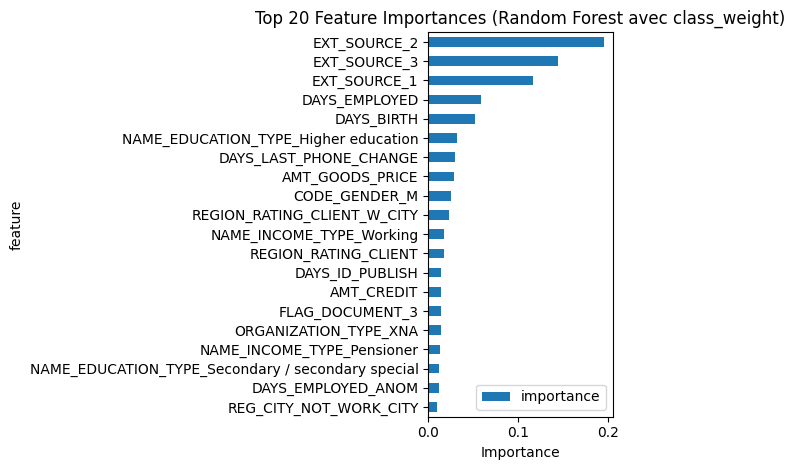

In [20]:
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_weighted.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(feature_importance.head(20))

# Visualisation
plt.figure(figsize=(12, 8))
feature_importance.head(20).plot.barh(x='feature', y='importance')
plt.title('Top 20 Feature Importances (Random Forest avec class_weight)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# SMOTE équilibre les classes en suréchantillonnant la classe minoritaire

In [21]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"   Avant SMOTE: {X_train.shape[0]} lignes")
print(f"   Après SMOTE: {X_train_smote.shape[0]} lignes")
print(f"\n   Distribution après SMOTE:")
print(f"     0: {(y_train_smote == 0).sum()} ({(y_train_smote == 0).mean()*100:.2f}%)")
print(f"     1: {(y_train_smote == 1).sum()} ({(y_train_smote == 1).mean()*100:.2f}%)")

   Avant SMOTE: 246008 lignes
   Après SMOTE: 452296 lignes

   Distribution après SMOTE:
     0: 226148 (50.00%)
     1: 226148 (50.00%)


# Logistic Regression sur données SMOTE et StratifiedKFold

In [22]:
with mlflow.start_run(run_name="LogisticRegression_SMOTE"):
    
    lr_smote = LogisticRegression(max_iter=500, random_state=42, solver='liblinear')
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_lr_smote = cross_validate(
        lr_smote, 
        X_train_smote, y_train_smote,  
        cv=skf,  
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'  
        },
        n_jobs=-1,
        verbose=0
    )

    lr_smote.fit(X_train_smote, y_train_smote)
    y_val_pred_proba_lr_s = lr_smote.predict_proba(X_val)[:, 1]
    y_val_pred_lr_s= lr_smote.predict (X_val)

    roc_auc_lr_s = cv_scores_lr_smote['test_roc_auc'].mean() 
    auc_pr_lr_s = cv_scores_lr_smote['test_auc_pr'].mean()
    accuracy_lr_s = accuracy_score(y_val, y_val_pred_lr_s)
    precision_lr_s = precision_score(y_val, y_val_pred_lr_s)
    recall_lr_s = recall_score(y_val, y_val_pred_lr_s)

    # log des paramètres
    mlflow.log_param("max_iter", 500)
    mlflow.log_param("solver", "liblinear")
    mlflow.log_param("class_weight", "smote")
    
    # log métrique
    mlflow.log_metric("roc_auc_lr_smote", roc_auc_lr_s)
    mlflow.log_metric("auc_pr_lr_smote", auc_pr_lr_s)
    mlflow.log_metric("accuracy_lr_smote", accuracy_lr_s)
    mlflow.log_metric("precision_lr_smote", precision_lr_s)
    mlflow.log_metric("recall_lr_smote", recall_lr_s)

    # Log modèle
    mlflow.sklearn.log_model(lr_smote, "model_lr_smote")

    print(f" ROC_AUC_lr_smote: {roc_auc_lr_s:.4f}")
    print(f" auc_pr_lr_smote: {auc_pr_lr_s:.4f}")
    print(f"Accuracy_lr_smote : {accuracy_lr_s:.4f}")
    print(f"Precision_lr_smote: {precision_lr_s:.4f}")
    print(f"Recall_lr_smote  : {recall_lr_s:.4f}")


2026/05/05 10:38:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_lr_smote: 0.6103
 auc_pr_lr_smote: 0.5798
Accuracy_lr_smote : 0.6301
Precision_lr_smote: 0.1147
Recall_lr_smote  : 0.5333


# Random Forest sur données SMOTE et StratifiedKFold

In [23]:
with mlflow.start_run(run_name="RandomForest_SMOTE"):

    rf_smote = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=0)
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_rf_smote = cross_validate(
        rf_smote, 
        X_train_smote, y_train_smote,  
        cv=skf,  
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'
        },
        n_jobs=-1,
        verbose=0
    )
    rf_smote.fit(X_train_smote, y_train_smote)
    y_val_pred_proba_rf_s = rf_smote.predict_proba(X_val)[:, 1]
    y_val_pred_rf_s= rf_smote.predict (X_val)

    roc_auc_rf_s = cv_scores_rf_smote['test_roc_auc'].mean() # associé à la cross validation en KFold
    auc_pr_rf_s = cv_scores_rf_smote['test_auc_pr'].mean()
    accuracy_rf_s = accuracy_score(y_val, y_val_pred_rf_s)
    precision_rf_s = precision_score(y_val, y_val_pred_rf_s)
    recall_rf_s = recall_score(y_val, y_val_pred_rf_s)

    # log des paramètres
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("class_weight", "smote")
    
    # log métrique
    mlflow.log_metric("roc_auc_rf_smote", roc_auc_rf_s)
    mlflow.log_metric("auc-pr_rf_smote", auc_pr_rf_s)
    mlflow.log_metric("accuracy_rf_smote", accuracy_rf_s)
    mlflow.log_metric("precision_rf_smote", precision_rf_s)
    mlflow.log_metric("recall_rf_smote", recall_rf_s)

    # Log modèle
    mlflow.sklearn.log_model(rf_smote, "model_rf_smote")

    print(f" ROC_AUC_rf_smote: {roc_auc_rf_s:.4f}")
    print(f" AUC_pr_rf_smote: {auc_pr_rf_s:.4f}")
    print(f"Accuracy_rf_smote : {accuracy_rf_s:.4f}")
    print(f"Precision_rf_smote: {precision_rf_s:.4f}")
    print(f"Recall_rf_smote  : {recall_rf_s:.4f}")


2026/05/05 10:40:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


 ROC_AUC_rf_smote: 0.9483
 AUC_pr_rf_smote: 0.9583
Accuracy_rf_smote : 0.8332
Precision_rf_smote: 0.1542
Recall_rf_smote  : 0.2377


# Feature importances de Random Forest avec SMOTE

Top 20 features les plus importantes:
                                   feature  importance
28                            EXT_SOURCE_2    0.078692
120   NAME_EDUCATION_TYPE_Higher education    0.069639
29                            EXT_SOURCE_3    0.062150
106                         FLAG_OWN_CAR_Y    0.050721
103             AMT_REQ_CREDIT_BUREAU_YEAR    0.050059
27                            EXT_SOURCE_1    0.046529
57                      NONLIVINGAREA_MODE    0.041357
15                              FLAG_PHONE    0.040162
75                OBS_60_CNT_SOCIAL_CIRCLE    0.034473
124             NAME_FAMILY_STATUS_Married    0.034124
43                       NONLIVINGAREA_AVG    0.032341
71                      NONLIVINGAREA_MEDI    0.029450
73                OBS_30_CNT_SOCIAL_CIRCLE    0.027858
222        WALLSMATERIAL_MODE_Stone, brick    0.027734
114  NAME_INCOME_TYPE_Commercial associate    0.025857
115             NAME_INCOME_TYPE_Pensioner    0.023683
212                  ORGANI

<Figure size 1200x800 with 0 Axes>

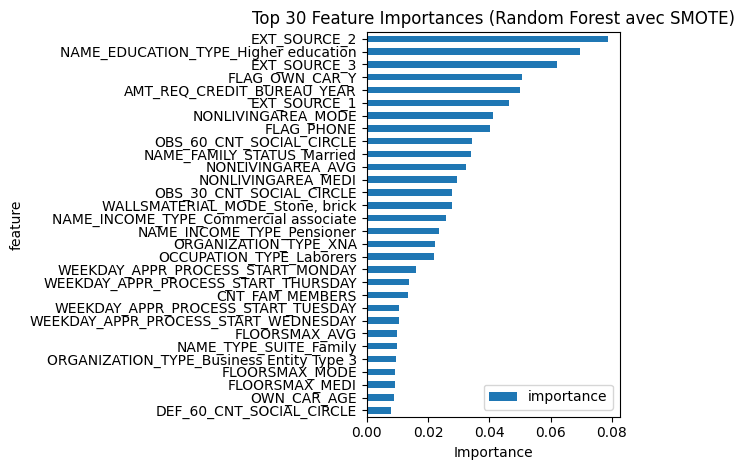

In [24]:
feature_importance = pd.DataFrame({
    'feature': X_train_smote.columns,
    'importance': rf_smote.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 features les plus importantes:")
print(feature_importance.head(20))

# Visualisation
plt.figure(figsize=(12, 8))
feature_importance.head(30).plot.barh(x='feature', y='importance')
plt.title('Top 30 Feature Importances (Random Forest avec SMOTE)')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Nettoyer les noms de colonnes suite erreur avec lightgbm ne supportant pas certains caracteres JSON

In [25]:
def clean_column_names(df):
    """Nettoie les noms de colonnes pour LightGBM"""
    new_columns = []
    for col in df.columns:
        # Remplacer les caractères spéciaux par des underscores
        col_clean = re.sub(r'[^A-Za-z0-9_]', '_', str(col))
        # Éviter les underscores multiples
        col_clean = re.sub(r'_+', '_', col_clean)
        # Enlever les underscores au début et à la fin
        col_clean = col_clean.strip('_')
        new_columns.append(col_clean)
    
    df.columns = new_columns
    return df

# application du nettoyage des colonnes

In [26]:
print(f"Avant: {X_train.columns[:5].tolist()} ...")

X_train = clean_column_names(X_train)
X_val = clean_column_names(X_val)
X_test = clean_column_names(X_test)

print(f"Après: {X_train.columns[:5].tolist()} ...")

# Vérifier qu'il n'y a plus de doublons
if X_train.columns.duplicated().any():
    print(" Attention: colonnes dupliquées détectées")
    # Ajouter un suffixe aux colonnes dupliquées
    X_train.columns = pd.io.common.dedup_names(X_train.columns, is_potential_multiindex=False)
    X_val.columns = X_train.columns
    X_test.columns = X_train.columns
    print(" Colonnes dupliquées renommées")

print(f"\n Nettoyage terminé")
print(f" Nombre de colonnes: {len(X_train.columns)}")

Avant: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'] ...
Après: ['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'] ...

 Nettoyage terminé
 Nombre de colonnes: 226


# Nettoyage supplémentaire des colonnes pour LightGBM

In [27]:
X.columns = X.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_train.columns = X_train.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)
X_val.columns = X_val.columns.str.replace('[^A-Za-z0-9_]', '_', regex=True)

[col for col in X.columns if not col.replace('_','').isalnum()]



[]

# LightGBM avec scale_pos_weight

In [28]:
# Calculer le ratio de déséquilibre
# Calcul du ratio sur tout y
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.1f}")

with mlflow.start_run(run_name="LightGBM_Scale_Pos_Weight"):   

    model_lgb = LGBMClassifier(
        objective='binary',
        boosting_type='gbdt',
        learning_rate=0.05,
        max_depth=5,
        num_leaves=15,
        n_estimators=100,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )

    # Cross-validation StratifiedKFold
    cv_scores_lgb = cross_validate(
        model_lgb,
        X,
        y,
        cv=skf,
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'   # AUC-PR correct
        },
        n_jobs=-1
    )

    roc_auc_lgb = cv_scores_lgb['test_roc_auc'].mean()
    auc_pr_lgb = cv_scores_lgb['test_auc_pr'].mean()


    # Fit sur train
    model_lgb.fit(X_train, y_train)

    y_val_pred_proba_lgb = model_lgb.predict_proba(X_val)[:, 1]
    y_val_pred_lgb = model_lgb.predict(X_val)

    accuracy_lgb = accuracy_score(y_val, y_val_pred_lgb)
    precision_lgb = precision_score(y_val, y_val_pred_lgb)
    recall_lgb = recall_score(y_val, y_val_pred_lgb)

    # Logging MLflow
    mlflow.log_param("objective", "binary")
    mlflow.log_param("boosting_type", "gbdt")
    mlflow.log_param("num_leaves", 15)
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("learning_rate", 0.05)
    mlflow.log_param("scale_pos_weight", scale_pos_weight)

    mlflow.log_metric("roc_auc_cv_mean", roc_auc_lgb)
    mlflow.log_metric("auc_pr_cv_mean", auc_pr_lgb)
    mlflow.log_metric("accuracy_val", accuracy_lgb)
    mlflow.log_metric("precision_val", precision_lgb)
    mlflow.log_metric("recall_val", recall_lgb)

    mlflow.lightgbm.log_model(model_lgb, "model_lgb")

    print(f"ROC_AUC_lgb (CV mean): {roc_auc_lgb:.4f}")
    print(f"auc_pr_lgb (CV mean): {auc_pr_lgb:.4f}")
    print(f"Accuracy_lgb (val): {accuracy_lgb:.4f}")
    print(f"Precision_lgb (val): {precision_lgb:.4f}")
    print(f"Recall_lgb (val): {recall_lgb:.4f}")

    print("LightGBM terminé")



scale_pos_weight: 11.4
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.349585 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11416
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 219
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482


2026/05/05 10:41:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/05 10:41:57 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.


ROC_AUC_lgb (CV mean): 0.7505
auc_pr_lgb (CV mean): 0.2322
Accuracy_lgb (val): 0.6869
Precision_lgb (val): 0.1619
Recall_lgb (val): 0.6892
LightGBM terminé


# XGBoost avec scale_pos_weight

In [29]:
scale_pos_weight_xgb = (y_train == 0).sum() / (y_train == 1).sum()
print(f"   scale_pos_weight: {scale_pos_weight_xgb:.2f}")

with mlflow.start_run(run_name="XGBoost_Scale_Pos_Weight"):      
    xgb_params = {
            'objective': 'binary:logistic',
            'eval_metric': 'auc',
            'max_depth': 5,
            'learning_rate': 0.05,
            'scale_pos_weight': scale_pos_weight_xgb,  # Gère le déséquilibre
            'verbosity': 0
        }
    
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    model_xgb = XGBClassifier( 
        objective='binary:logistic', 
        eval_metric='auc', 
        max_depth=5, 
        learning_rate=0.05, 
        scale_pos_weight=scale_pos_weight_xgb, 
        n_estimators=100 
    )
    
    # Cross-validation avec StratifiedKFold explicite
    cv_scores_xgb = cross_validate(
        model_xgb, 
        X, y,  
        cv=skf,  
        scoring={
            'roc_auc': 'roc_auc',
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'auc_pr': 'average_precision'
        },
        n_jobs=-1,
        verbose=0
    )

    roc_auc_xgb = cv_scores_xgb['test_roc_auc'].mean() # associé à la cross validation en KFold
    auc_pr_xgb = cv_scores_xgb['test_auc_pr'].mean()

    # refit sur train après la CV
    model_xgb.fit(X_train, y_train)

    y_val_pred_proba_xgb = model_xgb.predict_proba(X_val)[:, 1]
    y_val_pred_xgb = (y_val_pred_proba_xgb >= 0.5).astype(int)
    
    accuracy_xgb = accuracy_score(y_val, y_val_pred_xgb)
    precision_xgb = precision_score(y_val, y_val_pred_xgb)
    recall_xgb = recall_score(y_val, y_val_pred_xgb)

    # tracking automatique en one shot directement dans mlflow (param, metrique, modele)
    mlflow.xgboost.autolog()

    print(f" ROC_AUC_xgb: {roc_auc_xgb:.4f}")
    print(f" auc_pr_xgb: {auc_pr_xgb:.4f}")
    print(f"Accuracy_xgb : {accuracy_xgb:.4f}")
    print(f"Precision_xgb: {precision_xgb:.4f}")
    print(f"Recall_xgb  : {recall_xgb:.4f}")


   scale_pos_weight: 11.39
 ROC_AUC_xgb: 0.7502
 auc_pr_xgb: 0.2318
Accuracy_xgb : 0.6932
Precision_xgb: 0.1635
Recall_xgb  : 0.6804


# CatBoost avec auto_class_weights

In [30]:

with mlflow.start_run(run_name="CatBoost_Auto_Class_Weights"):

    cat = CatBoostClassifier(
            iterations=100,
            depth=5,
            learning_rate=0.05,
            auto_class_weights='Balanced',  # Gère automatiquement
            eval_metric='AUC',
            random_seed=42,
            verbose=0
        )
    
    scoring = {
        'roc_auc':   'roc_auc',
        'pr_auc':    make_scorer(average_precision_score, needs_proba=True),
        'accuracy':  'accuracy',
        'precision': make_scorer(precision_score, zero_division=0),
        'recall':    make_scorer(recall_score,    zero_division=0),
    }

    cv_results = cross_validate(
        cat, X, y,
        cv=skf,
        scoring=scoring,
        return_train_score=False,
    )

    roc_auc_cat  = cv_results['test_roc_auc'].mean()
    auc_pr_cat   = cv_results['test_pr_auc'].mean()
    
    cat.fit(X_train, y_train)
    
    y_val_pred_proba_cat = cat.predict_proba(X_val)[:, 1]
    y_val_pred_cat = (y_val_pred_proba_cat >= 0.5).astype(int)
    
    accuracy_cat = accuracy_score(y_val, y_val_pred_cat)
    precision_cat = precision_score(y_val, y_val_pred_cat)
    recall_cat = recall_score(y_val, y_val_pred_cat)

    # tracking automatique en one shot directement dans mlflow (param, metrique, modele)
    
    # Log modèle
    mlflow.sklearn.log_model(cat, name="model_CatBoost_Auto_Class_Weights")

    # log métrique
    mlflow.log_metric("roc_auc_cat", roc_auc_cat)
    mlflow.log_metric("auc_pr_cat", auc_pr_cat)
    mlflow.log_metric("accuracy_cat", accuracy_cat)
    mlflow.log_metric("precision_cat", precision_cat)
    mlflow.log_metric("recall_cat", recall_cat)

    print(f"   ROC_AUC_cat: {roc_auc_cat:.4f}")
    print(f"   auc_pr_cat: {auc_pr_cat:.4f}")
    print(f"   Accuracy_cat: {accuracy_cat:.4f}")
    print(f"   Precision_cat: {precision_cat:.4f}")
    print(f"   Recall_cat: {recall_cat:.4f}")

c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\sklearn\model_selection\_validation.py:945: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\sklearn\metrics\_scorer.py", line 166, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\sklearn\metrics\_scorer.py", line 417, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\sklearn\utils\_param_validation.py", line 196, in wrapper
    params = func_sig.bind(*args, **kwargs)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\chris\AppData\Local\Programs\Python\Python312\Lib\inspe

   ROC_AUC_cat: 0.7463
   auc_pr_cat: nan
   Accuracy_cat: 0.6881
   Precision_cat: 0.1613
   Recall_cat: 0.6818


# results summary

In [31]:

results_ROC_AUC = {
    'LR (class_weight)': roc_auc_lr_w,
    'RF (class_weight)': roc_auc_rf_w,
    'LR (SMOTE)': roc_auc_lr_s,
    'RF (SMOTE)': roc_auc_rf_s,
    'LightGBM (scale_pos_weight)': roc_auc_lgb,
    'XGBoost (scale_pos_weight)': roc_auc_xgb,
    'CatBoost (auto_class_weights)': roc_auc_cat
}

print("\n ROC AUC sur validation set:")
for name, score in sorted(results_ROC_AUC.items(), key=lambda x: x[1] if x[1] else 0, reverse=True):
    if score is not None:
        print(f"   {name:30s}: {score:.4f}")

# best model, meilleur modèle
best = max([(n, s) for n, s in results_ROC_AUC.items() if s is not None], key=lambda x: x[1])
print(f"\n Meilleur modèle ROC_AUC: {best[0]} (ROC_AUC = {best[1]:.4f})")


results_auc_pr = {
    'LR (class_weight)': auc_pr_lr_w,
    'RF (class_weight)': auc_pr_rf_w,
    'LR (SMOTE)': auc_pr_lr_s,
    'RF (SMOTE)': auc_pr_rf_s,
    'LightGBM (scale_pos_weight)': auc_pr_lgb,
    'XGBoost (scale_pos_weight)': auc_pr_xgb,
}

print("\n auc_pr sur validation set:")
for name, score in sorted(results_auc_pr.items(), key=lambda x: x[1] if x[1] else 0, reverse=True):
    if score is not None:
        print(f"   {name:30s}: {score:.4f}")


 ROC AUC sur validation set:
   RF (SMOTE)                    : 0.9483
   LightGBM (scale_pos_weight)   : 0.7505
   XGBoost (scale_pos_weight)    : 0.7502
   CatBoost (auto_class_weights) : 0.7463
   RF (class_weight)             : 0.7137
   LR (class_weight)             : 0.6589
   LR (SMOTE)                    : 0.6103

 Meilleur modèle ROC_AUC: RF (SMOTE) (ROC_AUC = 0.9483)

 auc_pr sur validation set:
   RF (SMOTE)                    : 0.9583
   LR (SMOTE)                    : 0.5798
   LightGBM (scale_pos_weight)   : 0.2322
   XGBoost (scale_pos_weight)    : 0.2318
   RF (class_weight)             : 0.1889
   LR (class_weight)             : 0.1444


In [32]:
# Optuna et les hyperparametres des modeles LightGBM, XGBoost et CatBoost

# Optuna + LightGBM + MLflow

[I 2026-05-05 10:44:14,166] A new study created in memory with name: no-name-98d53186-dd55-41e6-acc4-996a65499f37
[I 2026-05-05 10:44:31,282] Trial 0 finished with value: 0.18471807213816072 and parameters: {'learning_rate': 0.10860212885661308, 'num_leaves': 10, 'max_depth': 5, 'min_child_samples': 14, 'subsample': 0.9032883533075025, 'colsample_bytree': 0.9756001342143209, 'scale_pos_weight': 7.09205778370115}. Best is trial 0 with value: 0.18471807213816072.
[I 2026-05-05 10:44:45,426] Trial 1 finished with value: 0.1978018186277548 and parameters: {'learning_rate': 0.14124068340492893, 'num_leaves': 7, 'max_depth': 9, 'min_child_samples': 20, 'subsample': 0.9211798163313959, 'colsample_bytree': 0.9570417090995585, 'scale_pos_weight': 8.039376494458885}. Best is trial 1 with value: 0.1978018186277548.
[I 2026-05-05 10:44:58,298] Trial 2 finished with value: 0.18830301273505778 and parameters: {'learning_rate': 0.08678464399209827, 'num_leaves': 7, 'max_depth': 8, 'min_child_samples'

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.214049 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11455
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 221
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LightGBM] [Info] Number of positive: 13240, number of negative: 150765
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.250532 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11515
[LightGBM] [Info] Number of data points in the train set: 164005, number of used features: 218
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.4

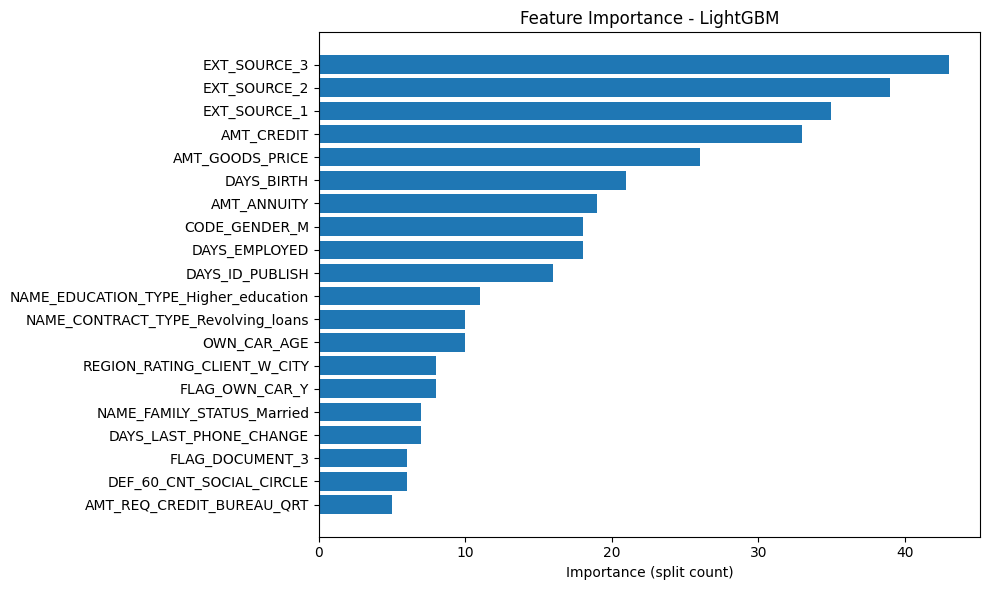

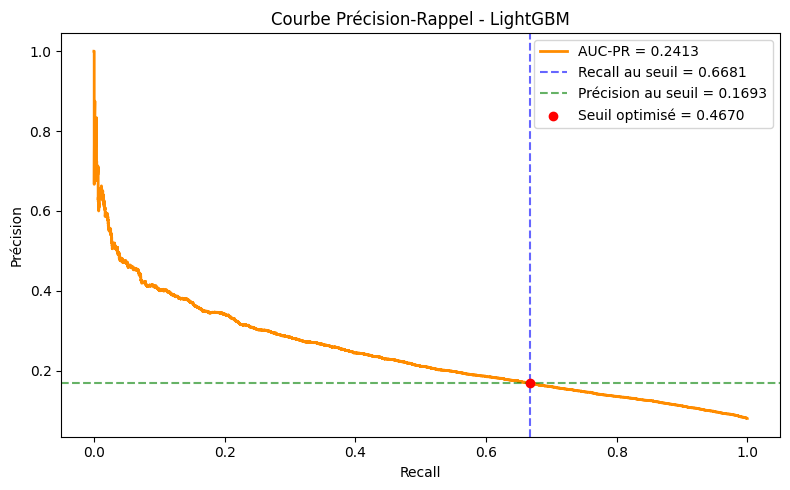

2026/05/05 10:48:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'LightGBM_Optuna_TunedThreshold' already exists. Creating a new version of this model...
2026/05/05 10:48:52 WARNING mlflow.tracking._model_registry.fluent: Run with id 05b1f8214ce34652a004731970e9c3fe has no artifacts at artifact path 'model', registering model based on models:/m-d24843376f0343429cfb1d93031e95b1 instead
Created version '5' of model 'LightGBM_Optuna_TunedThreshold'.


<ModelVersion: aliases=[], creation_timestamp=1777970932120, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1777970932120, metrics=None, model_id=None, name='LightGBM_Optuna_TunedThreshold', params=None, run_id='05b1f8214ce34652a004731970e9c3fe', run_link=None, source='models:/m-d24843376f0343429cfb1d93031e95b1', status='READY', status_message=None, tags={}, user_id=None, version=5>

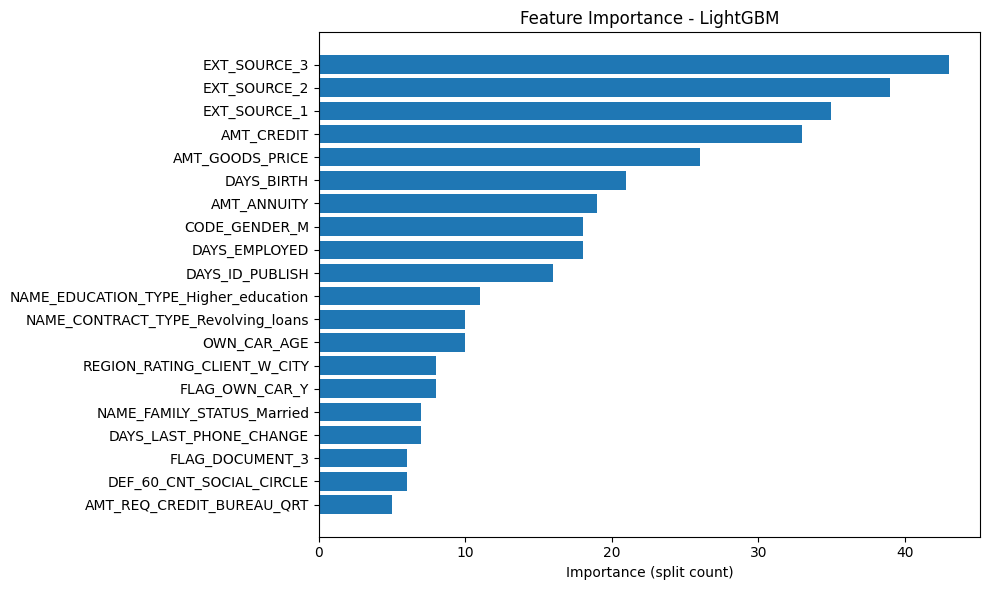

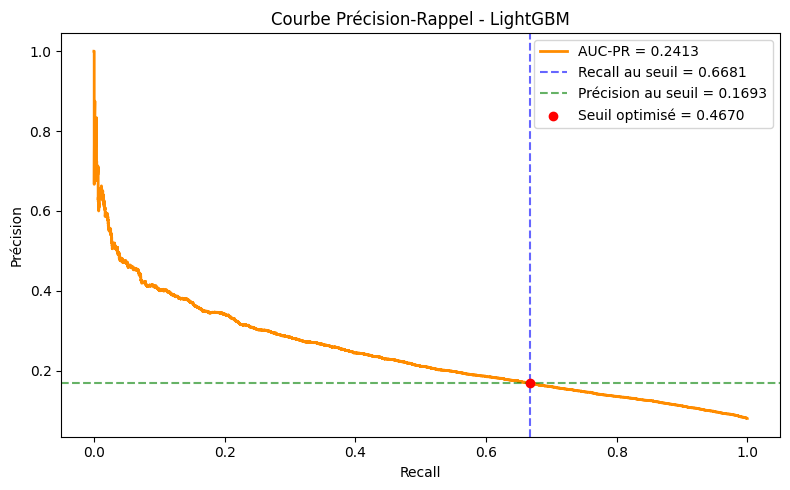

In [33]:

def objective(trial):

    params = {
        "objective": "binary",
        "metric": "auc",
        "boosting_type": "gbdt",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "num_leaves": trial.suggest_int("num_leaves", 5, 10),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 10)
    }

    model = lgb.LGBMClassifier(**params, n_estimators=50)

    # Probabilités en CV
    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    # on commence avec le seuil à 0.5
    y_pred_default = (y_proba > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_default).ravel()

    # Coût métier
    cost = fn * 10 + fp * 1

    # On veut maximiser AUC ET minimiser coût
    score = roc_auc - (cost / len(y_train))

    return score

# Optimisation
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

# Recherche du meilleur modele
best_params = study.best_params

# Scorer métier 
def cost_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(fn * 10 + fp * 1)   # négatif car on maximise le coût

scorer_metier = make_scorer(cost_scorer)

# TunedThresholdClassifierCV trouve le seuil optimal
model_best_lgb = lgb.LGBMClassifier(**best_params, n_estimators=50)

tuned_lgb = TunedThresholdClassifierCV(
    estimator=model_best_lgb,
    scoring=scorer_metier,    # coût métier
    cv=skf,                   
    refit=True                # réentraîne sur tout X_train avec le seuil trouvé
)

tuned_lgb.fit(X_train, y_train)
fitted_lgb_model = tuned_lgb.estimator_

best_threshold_lgb_opt = tuned_lgb.best_threshold_
print(f"Seuil optimal trouvé : {best_threshold_lgb_opt:.4f}")

y_val_proba = tuned_lgb.predict_proba(X_val)[:, 1]
y_val_pred = tuned_lgb.predict(X_val)  # seuil appliqué automatiquement

# Métriques métier sur le SET DE VALIDATION
roc_auc_val_lgb_opt  = roc_auc_score(y_val, y_val_proba)
tn_val_lgb_opt , fp_val_lgb_opt , fn_val_lgb_opt , tp_val_lgb_opt  = confusion_matrix(y_val, y_val_pred).ravel()
cost_val_lgb_opt  = fn_val_lgb_opt  * 10 + fp_val_lgb_opt  * 1
score_val_lgb_opt  = roc_auc_val_lgb_opt  - (cost_val_lgb_opt  / len(y_val))

# Précision / Recall au seuil optimisé
precision_lgb_opt = precision_score(y_val, y_val_pred)
recall_lgb_opt    = recall_score(y_val, y_val_pred)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba)
auc_pr_lgb_opt = auc(recalls, precisions)

print(f"  ROC-AUC_lgb_opt               : {roc_auc_val_lgb_opt :.4f}")
print(f"  AUC-PR_lgb_opt               : {auc_pr_lgb_opt:.4f}")
print(f"  Seuil optimisé_lgb_opt       : {best_threshold_lgb_opt:.4f}")
print(f"  Précision_lgb_opt             : {precision_lgb_opt:.4f}")
print(f"  Recall_lgb_opt                : {recall_lgb_opt:.4f}")
print(f"  Faux Négatifs (fn)_lgp_opt    : {fn_val_lgb_opt }  (coût x10 → {fn_val_lgb_opt  * 10})")
print(f"  Faux Positifs (fp)_lgp_opt     : {fp_val_lgb_opt }  (coût x1  → {fp_val_lgb_opt  * 1})")
print(f"  Coût métier total_lgp_opt      : {cost_val_lgb_opt }")
print(f"  Score Optuna (val)_lgp_opt     : {score_val_lgb_opt :.4f}")

# Feature Importance LightGBM
feature_importance = tuned_lgb.estimator_.feature_importances_
feature_names = X_train.columns

# Tri par importance décroissante 
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (split count)")
plt.title("Feature Importance - LightGBM")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel
# -----------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_lgb_opt:.4f}")
plt.axvline(x=recall_lgb_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_lgb_opt:.4f}")
plt.axhline(y=precision_lgb_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_lgb_opt:.4f}")
plt.scatter([recall_lgb_opt], [precision_lgb_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_lgb_opt:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - LightGBM")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Log avec mlflow
with mlflow.start_run(run_name="LightGBM_Optuna_TunedThreshold") as run:

    mlflow.log_params(best_params)
    mlflow.log_param("optimized_threshold", best_threshold_lgb_opt)

    mlflow.log_metric("roc_auc_lgb_opt ", roc_auc_val_lgb_opt )
    mlflow.log_metric("auc_pr_lgb_opt", auc_pr_lgb_opt)
    mlflow.log_metric("precision_lgb_opt", precision_lgb_opt)
    mlflow.log_metric("recall_lgb_opt", recall_lgb_opt)
    mlflow.log_metric("fn_val_lgb_opt ", fn_val_lgb_opt )
    mlflow.log_metric("fp_val_lgb_opt ", fp_val_lgb_opt )
    mlflow.log_metric("cost_val_lgb_opt ", cost_val_lgb_opt )
    mlflow.log_metric("score_lgb_opt ", score_val_lgb_opt )

    # On logue le wrapper complet
    mlflow.sklearn.log_model(tuned_lgb, "model")

    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (split count)")
    ax.set_title("Feature Importance - LightGBM")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_lgb_opt:.4f}")
    ax2.axvline(x=recall_lgb_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_lgb_opt:.4f}")
    ax2.axhline(y=precision_lgb_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_lgb_opt:.4f}")
    ax2.scatter([recall_lgb_opt], [precision_lgb_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_lgb_opt:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - LightGBM")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "LightGBM_Optuna_TunedThreshold"
)


# Optuna + XGBoost + MLflow

[I 2026-05-05 10:48:55,125] A new study created in memory with name: no-name-cdab1a5e-671b-4fd2-893a-960cf90de836
[I 2026-05-05 10:49:17,816] Trial 0 finished with value: 0.19005134732875184 and parameters: {'learning_rate': 0.13643739546116296, 'max_depth': 4, 'min_child_weight': 18, 'subsample': 0.839684784345273, 'colsample_bytree': 0.9576452656829161, 'scale_pos_weight': 7.273254739096048}. Best is trial 0 with value: 0.19005134732875184.
[I 2026-05-05 10:49:48,774] Trial 1 finished with value: 0.07256001364223907 and parameters: {'learning_rate': 0.03347168810369606, 'max_depth': 8, 'min_child_weight': 7, 'subsample': 0.9634595671704136, 'colsample_bytree': 0.6208382685032949, 'scale_pos_weight': 5.486359606586925}. Best is trial 0 with value: 0.19005134732875184.
[I 2026-05-05 10:50:12,191] Trial 2 finished with value: 0.20579955403410832 and parameters: {'learning_rate': 0.14191202272905518, 'max_depth': 4, 'min_child_weight': 11, 'subsample': 0.847475245935921, 'colsample_bytre

Seuil optimal trouvé : 0.4557


2026/05/05 10:59:48 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/05/05 11:00:01 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\chris\Initiez_vous_au_ML_

  ROC-AUC_xgb_opt               : 0.7565
  AUC-PR_xgb_opt               : 0.2449
  Seuil optimisé_xgb_opt       : 0.4557
  Précision_xgb_opt             : 0.1697
  Recall_xgb_opt                : 0.6689
  Faux Négatifs (fn)_xgb_opt    : 1644  (coût x10: 16440)
  Faux Positifs (fp)_xgb_opt    : 16244  (coût x1 : 16244)
  Coût métier total_xgb_opt     : 32684
  Score Optuna (val)_xgb_opt    : 0.2250


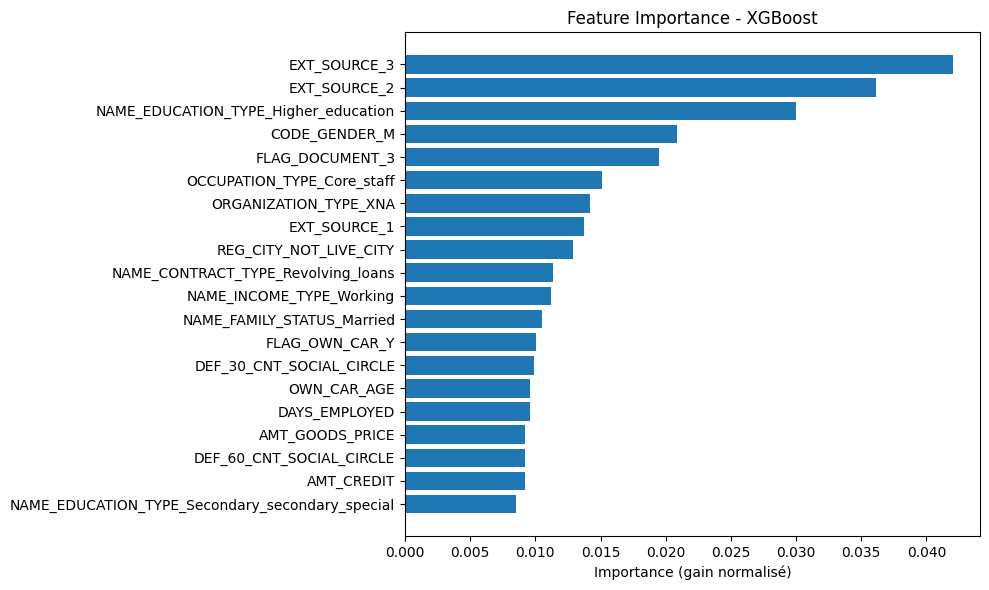

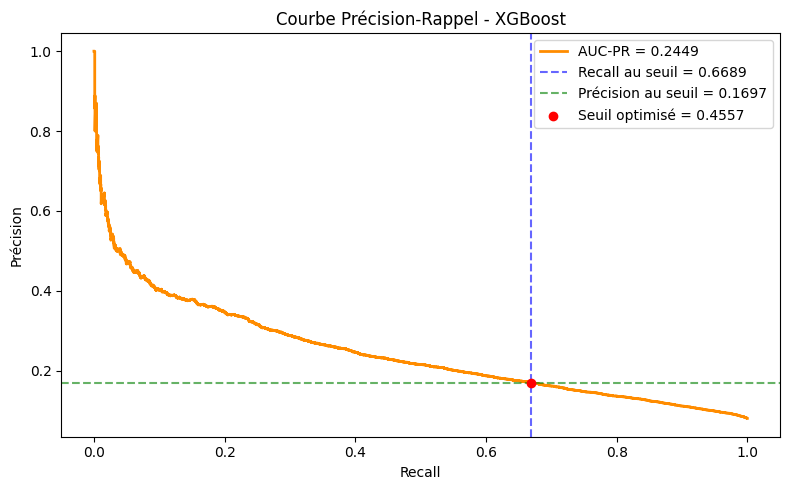

2026/05/05 11:00:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'XGBoost_Optuna_TunedThreshold' already exists. Creating a new version of this model...
2026/05/05 11:00:08 WARNING mlflow.tracking._model_registry.fluent: Run with id 9d0720da91174316b010148b617200f2 has no artifacts at artifact path 'model', registering model based on models:/m-c6923ef3c35b4b27806d5304974cbb94 instead
Created version '5' of model 'XGBoost_Optuna_TunedThreshold'.


<ModelVersion: aliases=[], creation_timestamp=1777971608359, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1777971608359, metrics=None, model_id=None, name='XGBoost_Optuna_TunedThreshold', params=None, run_id='9d0720da91174316b010148b617200f2', run_link=None, source='models:/m-c6923ef3c35b4b27806d5304974cbb94', status='READY', status_message=None, tags={}, user_id=None, version=5>

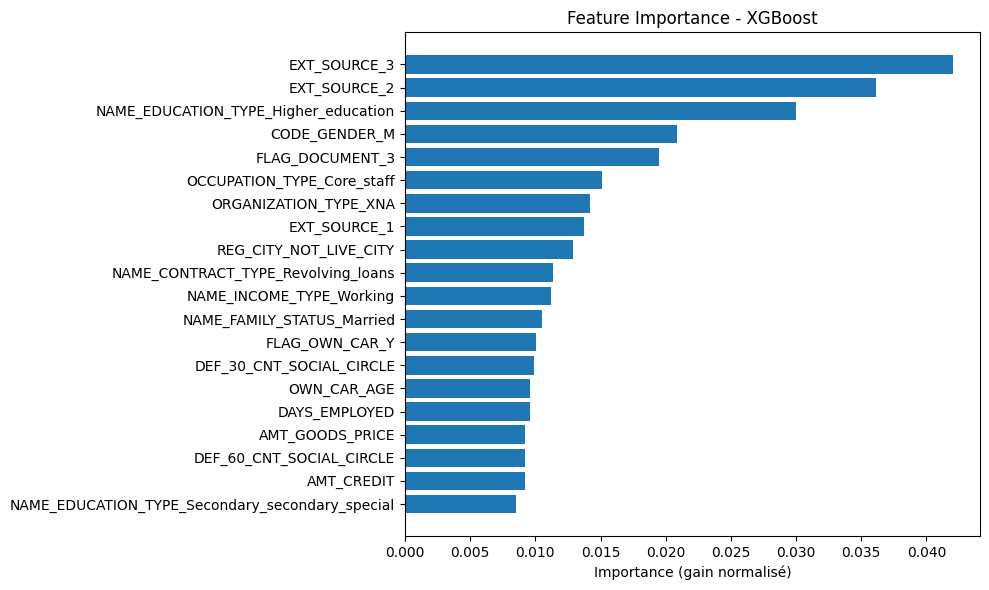

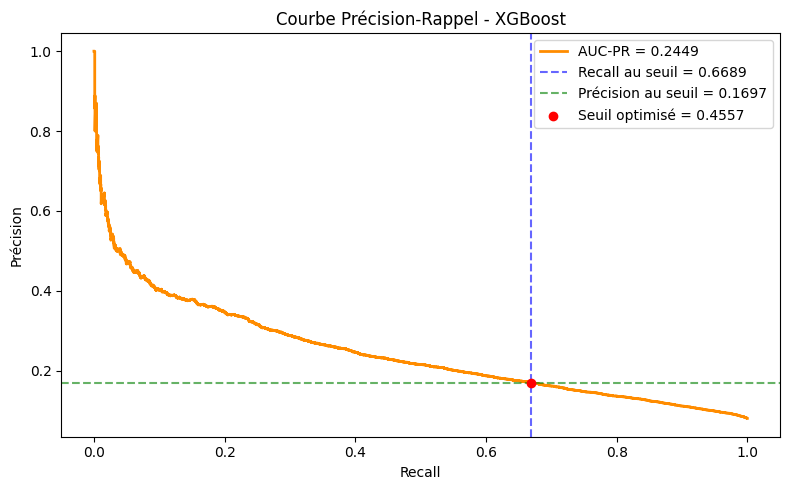

In [34]:

def objective_xgb(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "booster": "gbtree",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 5, 10),
        "n_estimators": 50,
        "use_label_encoder": False,
    }

    model = xgb.XGBClassifier(**params, verbosity=0)

    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

     # Seuil fixe à 0.5 
    y_pred_default = (y_proba > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_default).ravel()
    cost = fn * 10 + fp * 1
    score = roc_auc - (cost / len(y_train))

    return score


study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=20)

best_params_xgb = study_xgb.best_params

# Scorer métier
def cost_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return -(fn * 10 + fp * 1)

scorer_metier = make_scorer(cost_scorer)

# TunedThresholdClassifierCV

model_best_xgb = xgb.XGBClassifier(**best_params_xgb, verbosity=0)
tuned_xgb = TunedThresholdClassifierCV(
    estimator=model_best_xgb,
    scoring=scorer_metier,
    cv=skf,
    refit=True
)

tuned_xgb.fit(X_train, y_train)
fitted_xgb_model = tuned_xgb.estimator_

best_threshold_xgb = tuned_xgb.best_threshold_
print(f"Seuil optimal trouvé : {best_threshold_xgb:.4f}")


# Métriques sur X_val
y_val_proba_xgb = tuned_xgb.predict_proba(X_val)[:, 1]
y_val_pred_xgb  = tuned_xgb.predict(X_val)        # seuil appliqué automatiquement

roc_auc_xgb_opt = roc_auc_score(y_val, y_val_proba_xgb)

tn_val_xgb_opt, fp_val_xgb_opt, fn_val_xgb_opt, tp_val_xgb_opt = confusion_matrix(y_val, y_val_pred_xgb).ravel()
cost_val_xgb_opt = fn_val_xgb_opt * 10 + fp_val_xgb_opt * 1
score_val_xgb_opt = roc_auc_xgb_opt - (cost_val_xgb_opt / len(y_val))

# Précision / Recall au seuil optimisé
precision_xgb_opt = precision_score(y_val, y_val_pred_xgb)
recall_xgb_opt    = recall_score(y_val, y_val_pred_xgb)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_xgb)
auc_pr_xgb_opt = auc(recalls, precisions)

print(f"  ROC-AUC_xgb_opt               : {roc_auc_xgb_opt :.4f}")
print(f"  AUC-PR_xgb_opt               : {auc_pr_xgb_opt:.4f}")
print(f"  Seuil optimisé_xgb_opt       : {best_threshold_xgb:.4f}")
print(f"  Précision_xgb_opt             : {precision_xgb_opt:.4f}")
print(f"  Recall_xgb_opt                : {recall_xgb_opt:.4f}")
print(f"  Faux Négatifs (fn)_xgb_opt    : {fn_val_xgb_opt}  (coût x10: {fn_val_xgb_opt * 10})")
print(f"  Faux Positifs (fp)_xgb_opt    : {fp_val_xgb_opt}  (coût x1 : {fp_val_xgb_opt * 1})")
print(f"  Coût métier total_xgb_opt     : {cost_val_xgb_opt}")
print(f"  Score Optuna (val)_xgb_opt    : {score_val_xgb_opt:.4f}")

# Feature Importance XGBoost
feature_importance = tuned_xgb.estimator_.feature_importances_
feature_names = X_train.columns

# Tri par importance décroissante
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (gain normalisé)")
plt.title("Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_xgb_opt:.4f}")
plt.axvline(x=recall_xgb_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_xgb_opt:.4f}")
plt.axhline(y=precision_xgb_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_xgb_opt:.4f}")
plt.scatter([recall_xgb_opt], [precision_xgb_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_xgb:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - XGBoost")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# mlflow
with mlflow.start_run(run_name="XGBoost_Optuna_TunedThreshold") as run:
    mlflow.log_params(best_params_xgb)
    mlflow.log_param("optimized_threshold_xgb", best_threshold_xgb)

    mlflow.log_metric("roc_auc_xgb_opt", roc_auc_xgb_opt)
    mlflow.log_metric("auc_pr_xgb_opt", auc_pr_xgb_opt)
    mlflow.log_metric("precision_xgb_opt", precision_xgb_opt)
    mlflow.log_metric("recall_xgb_opt", recall_xgb_opt)
    mlflow.log_metric("fn_xgb_opt", fn_val_xgb_opt)
    mlflow.log_metric("fp_xgb_opt", fp_val_xgb_opt)
    mlflow.log_metric("cost_xgb_opt", cost_val_xgb_opt)
    mlflow.log_metric("score_xgb_opt", score_val_xgb_opt)

    # wrapper sklearn:
    mlflow.sklearn.log_model(tuned_xgb, "model")

    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (gain normalisé)")
    ax.set_title("Feature Importance - XGBoost")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_xgb_opt:.4f}")
    ax2.axvline(x=recall_xgb_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_xgb_opt:.4f}")
    ax2.axhline(y=precision_xgb_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_xgb_opt:.4f}")
    ax2.scatter([recall_xgb_opt], [precision_xgb_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_xgb:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - XGBoost")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "XGBoost_Optuna_TunedThreshold"
)


# Optuna + CatBoost + MLflow

[I 2026-05-05 11:50:27,115] A new study created in memory with name: no-name-8855f74d-3be9-4a8a-bb2b-55e55742fc17
[I 2026-05-05 11:50:55,672] Trial 0 finished with value: 0.05720838035508968 and parameters: {'learning_rate': 0.18093603497735444, 'depth': 9, 'min_data_in_leaf': 8, 'subsample': 0.9789411459560844, 'colsample_bylevel': 0.9562151507602772, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.05720838035508968.
[I 2026-05-05 11:51:06,697] Trial 1 finished with value: 0.19111618794915375 and parameters: {'learning_rate': 0.1532213414136626, 'depth': 3, 'min_data_in_leaf': 16, 'subsample': 0.910081703913668, 'colsample_bylevel': 0.6259444849423506, 'auto_class_weights': 'Balanced'}. Best is trial 1 with value: 0.19111618794915375.
[I 2026-05-05 11:51:19,007] Trial 2 finished with value: -0.035119000581928406 and parameters: {'learning_rate': 0.03203388788824173, 'depth': 4, 'min_data_in_leaf': 18, 'subsample': 0.9490701426020761, 'colsample_bylevel': 0.6447523

Seuil optimal trouvé : 0.5268
  ROC-AUC_cat_opt               : 0.7521
  auc_pr_cat_opt               : 0.2384
  Seuil optimisé_cat_opt        : 0.5268
  Précision_cat_opt             : 0.1732
  Recall_cat_opt               : 0.6407
  Faux Négatifs (fn)_cat_opt    : 1784  (coût x10 → 17840)
  Faux Positifs (fp)_cat_opt    : 15186  (coût x1  → 15186)
  Coût métier total_cat_opt     : 33026
  Score Optuna (val)_cat_opt    : 0.2151


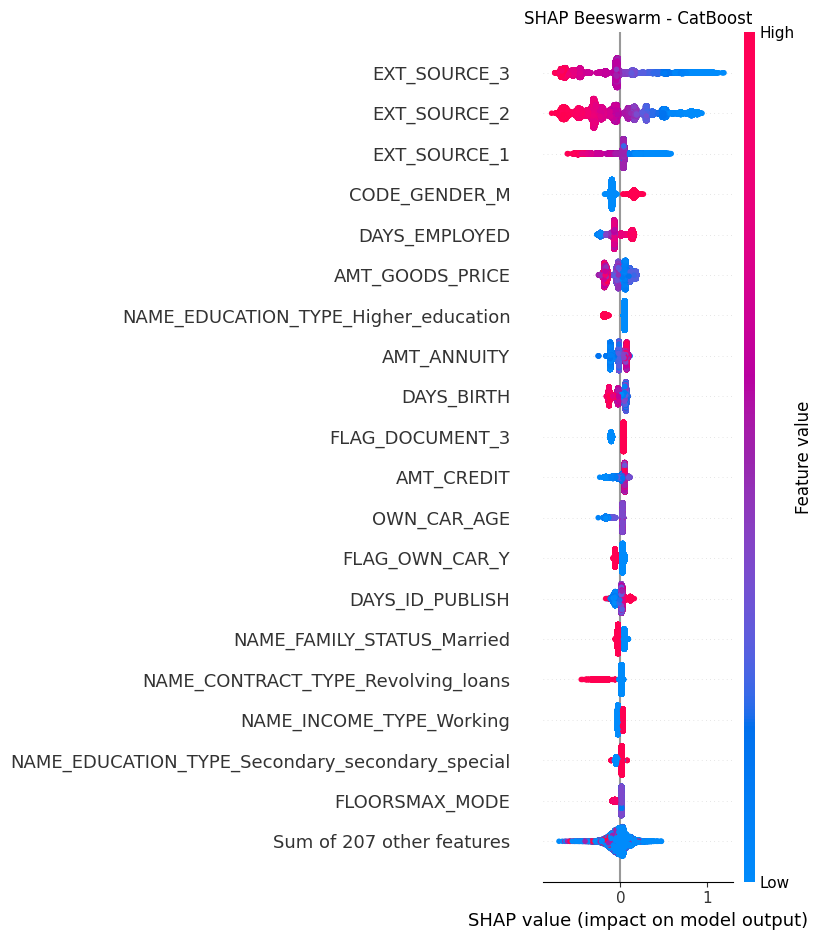

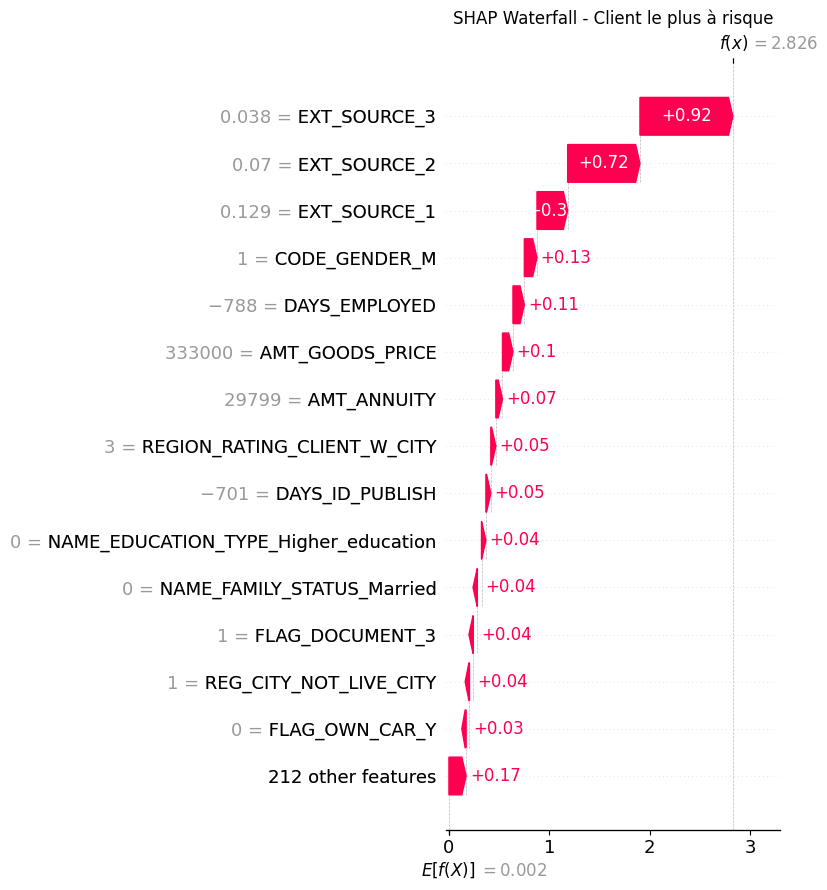

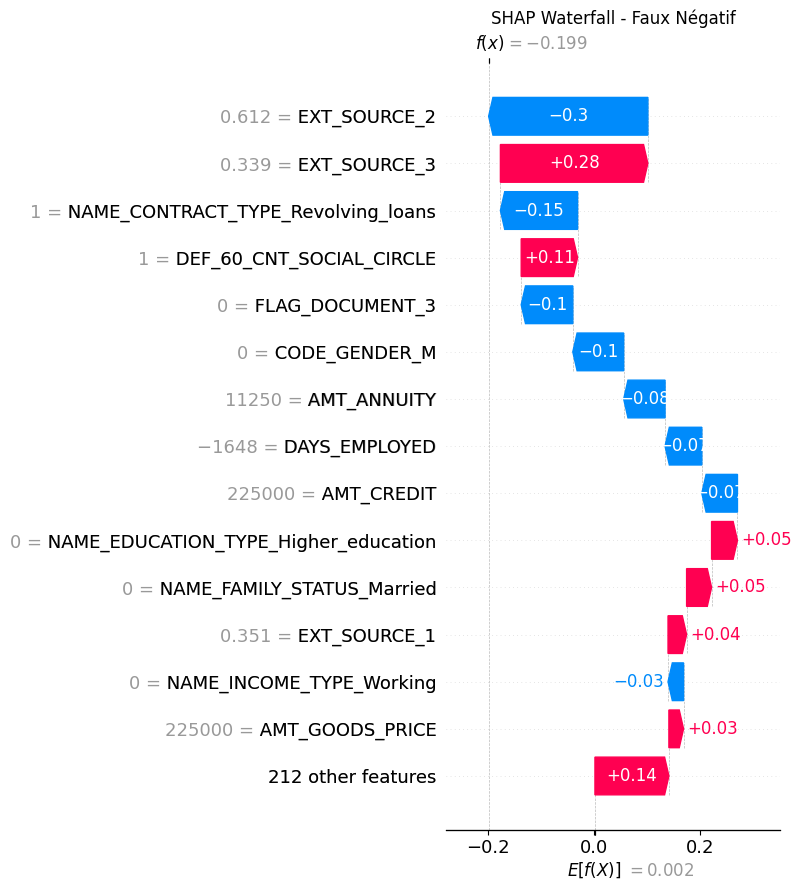

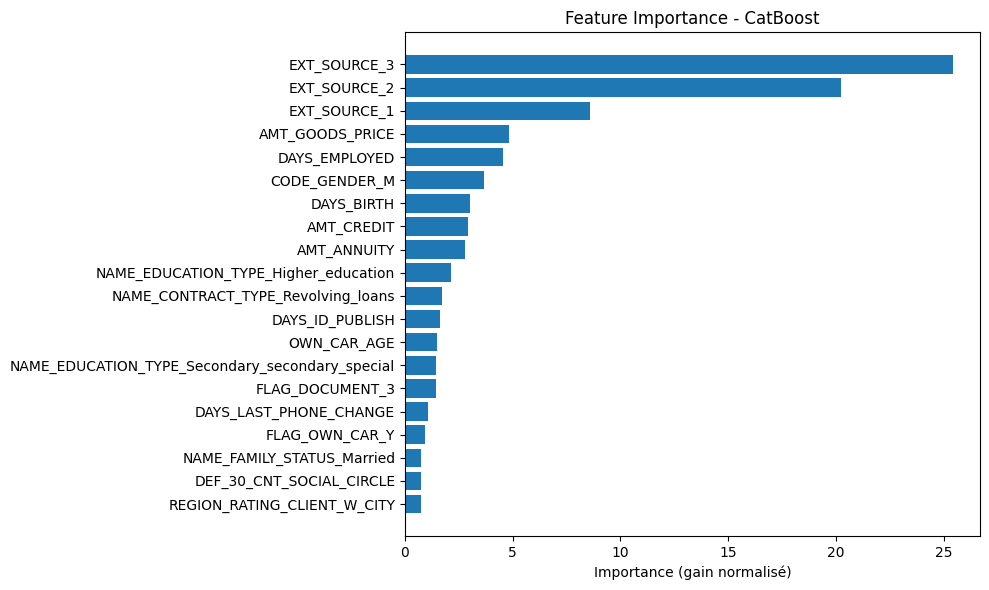

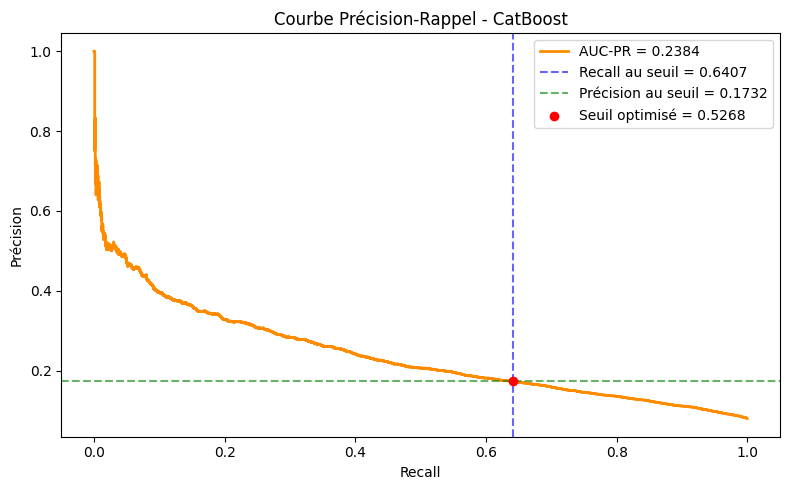

c:\Users\chris\Initiez_vous_au_ML_Ops\venv312\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/05 11:57:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Registered model 'CatBoost_Optuna_TunedThreshold' already exists. Creating a new version of this model...
2026/05/05 

<ModelVersion: aliases=[], creation_timestamp=1777975079442, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1777975079442, metrics=None, model_id=None, name='CatBoost_Optuna_TunedThreshold', params=None, run_id='e43dd12fde914ae98f3ccd9b6ee3a634', run_link=None, source='models:/m-736d091d85ae4f39b54fedb7a32230d7', status='READY', status_message=None, tags={}, user_id=None, version=7>

In [52]:

def objective_cat(trial):

    params = {
        "loss_function": "Logloss",
        "eval_metric": "AUC",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
        "depth": trial.suggest_int("depth", 3, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 5, 20),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "auto_class_weights": trial.suggest_categorical("auto_class_weights", ["Balanced", "SqrtBalanced"]),
        "iterations": 50,
        "verbose": 0,
    }

    model = CatBoostClassifier(**params)

    y_proba = cross_val_predict(
        model, X_train, y_train,
        cv=skf,
        method="predict_proba",
    )[:, 1]

    roc_auc = roc_auc_score(y_train, y_proba)

    
    y_pred_default = (y_proba > 0.5).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_train, y_pred_default).ravel()
    cost = fn * 10 + fp * 1
    score = roc_auc - (cost / len(y_train))

    return score


study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=20)

best_params_cat = study_cat.best_params

# Modèle avec les meilleurs hyperparamètres
model_best_cat = CatBoostClassifier(**best_params_cat, iterations=50,verbose=0)

# TunedThresholdClassifierCV optimise le seuil via CV 
# Scorer métier 
def cost_scorer(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    cost = fn * 10 + fp * 1
    return -cost  # on maximise donc on minimise le coût -

scorer_metier = make_scorer(cost_scorer)

tuned_cat = TunedThresholdClassifierCV(
    estimator=model_best_cat,
    scoring=scorer_metier,     # optimise le coût métier
    cv=skf,                   
    refit=True                 # réentraîne sur tout X_train avec le seuil trouvé
)

tuned_cat.fit(X_train, y_train)
fitted_cat_model = tuned_cat.estimator_

# Seuil trouvé automatiquement
best_threshold_cat = tuned_cat.best_threshold_
print(f"Seuil optimal trouvé : {best_threshold_cat:.4f}")

# Prédictions et métriques sur X_val 
y_val_proba_cat = tuned_cat.predict_proba(X_val)[:, 1]
y_val_pred_cat = tuned_cat.predict(X_val) # on appkique le seuil optimal

roc_auc_cat_opt = roc_auc_score(y_val, y_val_proba_cat)

tn_val_cat_opt , fp_val_cat_opt, fn_val_cat_opt , tp_val_cat_opt  = confusion_matrix(y_val, y_val_pred_cat).ravel()
cost_val_cat_opt  = fn_val_cat_opt  * 10 + fp_val_cat_opt  * 1
score_val_cat_opt  = roc_auc_cat_opt  - (cost_val_cat_opt  / len(y_val))

# Précision / Recall au seuil optimisé
precision_cat_opt = precision_score(y_val, y_val_pred_cat)
recall_cat_opt    = recall_score(y_val, y_val_pred_cat)

# Courbe Précision-Rappel + AUC-PR
precisions, recalls, _ = precision_recall_curve(y_val, y_val_proba_cat)
auc_pr_cat_opt = auc(recalls, precisions)

print(f"  ROC-AUC_cat_opt               : {roc_auc_cat_opt:.4f}")
print(f"  auc_pr_cat_opt               : {auc_pr_cat_opt:.4f}")
print(f"  Seuil optimisé_cat_opt        : {best_threshold_cat:.4f}")
print(f"  Précision_cat_opt             : {precision_cat_opt:.4f}")
print(f"  Recall_cat_opt               : {recall_cat_opt:.4f}")
print(f"  Faux Négatifs (fn)_cat_opt    : {fn_val_cat_opt}  (coût x10 → {fn_val_cat_opt * 10})")
print(f"  Faux Positifs (fp)_cat_opt    : {fp_val_cat_opt}  (coût x1  → {fp_val_cat_opt * 1})")
print(f"  Coût métier total_cat_opt     : {cost_val_cat_opt}")
print(f"  Score Optuna (val)_cat_opt    : {score_val_cat_opt:.4f}")


# Feature Importance CatBoost
feature_importance = tuned_cat.estimator_.get_feature_importance()
feature_names = X_train.columns
sorted_idx = feature_importance.argsort()[::-1]
sorted_importance = feature_importance[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
plt.xlabel("Importance (gain normalisé)")
plt.title("Feature Importance - CatBoost")
plt.tight_layout()
plt.show()

# Courbe Précision-Rappel

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, color="darkorange", lw=2,
         label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
plt.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
            label=f"Recall au seuil = {recall_cat_opt:.4f}")
plt.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
            label=f"Précision au seuil = {precision_cat_opt:.4f}")
plt.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
            label=f"Seuil optimisé = {best_threshold_cat:.4f}")
plt.xlabel("Recall")
plt.ylabel("Précision")
plt.title("Courbe Précision-Rappel - CatBoost")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

with mlflow.start_run(run_name="CatBoost_Optuna_TunedThreshold") as run:

    mlflow.log_params(best_params_cat)
    mlflow.log_param("optimized_threshold", best_threshold_cat)

    mlflow.log_metric("roc_auc_cat_opt", roc_auc_cat_opt)
    mlflow.log_metric("auc_pr_cat_opt", auc_pr_cat_opt)
    mlflow.log_metric("precision_cat_opt", precision_cat_opt)
    mlflow.log_metric("recall_cat_opt", recall_cat_opt)
    mlflow.log_metric("fn_val_cat_opt", fn_val_cat_opt)
    mlflow.log_metric("fp_val_cat_opt", fp_val_cat_opt)
    mlflow.log_metric("cost_val_cat_opt", cost_val_cat_opt)
    mlflow.log_metric("score_val_cat_opt", score_val_cat_opt)

    # inférer la signature depuis X_train
    signature = infer_signature(X_train, tuned_cat.predict_proba(X_val)[:, 1])

    # On logue le wrapper complet
    mlflow.sklearn.log_model(tuned_cat,
        "model",
        signature=signature,
        input_example=X_val.iloc[:15]   # 15 lignes d'exemple — très utile pour FastAPI
    )
    
    # Feature importance figure
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(sorted_names[:20][::-1], sorted_importance[:20][::-1])
    ax.set_xlabel("Importance (gain normalisé)")
    ax.set_title("Feature Importance - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig, "feature_importance.png")

    # Courbe PR figure
    fig_pr, ax2 = plt.subplots(figsize=(8, 5))
    ax2.plot(recalls, precisions, color="darkorange", lw=2,
             label=f"AUC-PR = {auc_pr_cat_opt:.4f}")
    ax2.axvline(x=recall_cat_opt, color="blue", linestyle="--", alpha=0.6,
                label=f"Recall au seuil = {recall_cat_opt:.4f}")
    ax2.axhline(y=precision_cat_opt, color="green", linestyle="--", alpha=0.6,
                label=f"Précision au seuil = {precision_cat_opt:.4f}")
    ax2.scatter([recall_cat_opt], [precision_cat_opt], color="red", zorder=5,
                label=f"Seuil optimisé = {best_threshold_cat:.4f}")
    ax2.set_xlabel("Recall")
    ax2.set_ylabel("Précision")
    ax2.set_title("Courbe Précision-Rappel - CatBoost")
    ax2.legend(loc="upper right")
    plt.tight_layout()
    mlflow.log_figure(fig_pr, "precision_recall_curve.png")

    # Récupération automatique du run_id
    run_id = run.info.run_id

# Register
mlflow.register_model(
    f"runs:/{run_id}/model",
    "CatBoost_Optuna_TunedThreshold"
)

In [36]:
print(type(model_best_cat))
print(type(tuned_cat))  # ou le nom de votre wrapper

<class 'catboost.core.CatBoostClassifier'>
<class 'sklearn.model_selection._classification_threshold.TunedThresholdClassifierCV'>


# Résumé comparatif des 3 modèles Optimisés

In [37]:
summary_data = {
    "Modèle": ["LightGBM_opt", "XGBoost_opt", "CatBoost_opt"],
    "Seuil optimisé": [best_threshold_lgb_opt, best_threshold_xgb, best_threshold_cat],
    "ROC-AUC": [roc_auc_val_lgb_opt, roc_auc_xgb_opt, roc_auc_cat_opt],
    "AUC-PR": [auc_pr_lgb_opt,auc_pr_xgb_opt,auc_pr_cat_opt],
    "Précision": [precision_lgb_opt,precision_xgb_opt,precision_cat_opt],
    "Recall": [recall_lgb_opt,recall_xgb_opt,recall_cat_opt],
    "FN": [fn_val_lgb_opt, fn_val_xgb_opt, fn_val_cat_opt],
    "Coût FN": [fn_val_lgb_opt * 10, fn_val_xgb_opt * 10, fn_val_cat_opt * 10],
    "FP": [fp_val_lgb_opt, fp_val_xgb_opt, fp_val_cat_opt],
    "Coût FP": [fp_val_lgb_opt * 1, fp_val_xgb_opt * 1, fp_val_cat_opt * 1],
    "Coût total": [cost_val_lgb_opt, cost_val_xgb_opt, cost_val_cat_opt],
    "Score": [score_val_lgb_opt, score_val_xgb_opt, score_val_cat_opt],
}

df_summary = pd.DataFrame(summary_data).set_index("Modèle")

# Arrondi des colonnes float
float_cols = ["Seuil optimisé", "ROC-AUC", "AUC-PR", "Précision", "Recall", "Score"]
df_summary[float_cols] = df_summary[float_cols].round(4)

# Affichage
print("Comparaison des modèles - Set de Validation")
print(df_summary.to_string())

Comparaison des modèles - Set de Validation
              Seuil optimisé  ROC-AUC  AUC-PR  Précision  Recall    FN  Coût FN     FP  Coût FP  Coût total   Score
Modèle                                                                                                             
LightGBM_opt          0.4670   0.7538  0.2413     0.1693  0.6681  1648    16480  16271    16271       32751  0.2213
XGBoost_opt           0.4557   0.7565  0.2449     0.1697  0.6689  1644    16440  16244    16244       32684  0.2250
CatBoost_opt          0.5183   0.7510  0.2370     0.1689  0.6506  1735    17350  15895    15895       33245  0.2105


#  Log MLflow — un run par modèle + un run résumé "Comparaison_3_Modeles" (onglet Compare de mlflow)

In [38]:

with mlflow.start_run(run_name="Comparaison_3_Modeles"):

    for _, row in df_summary.reset_index().iterrows():
        modele = row["Modèle"]
        with mlflow.start_run(run_name=f"Comparaison_{modele}", nested=True):
            mlflow.log_metric("seuil_optimise", row["Seuil optimisé"])
            mlflow.log_metric("roc_auc", row["ROC-AUC"])
            mlflow.log_metric("auc_pr", row["AUC-PR"])
            mlflow.log_metric("Précision", row["Précision"])
            mlflow.log_metric("Recall", row["Recall"])
            mlflow.log_metric("fn", row["FN"])
            mlflow.log_metric("cout_fn", row["Coût FN"])
            mlflow.log_metric("fp", row["FP"])
            mlflow.log_metric("cout_fp", row["Coût FP"])
            mlflow.log_metric("cout_total", row["Coût total"])
            mlflow.log_metric("score", row["Score"])

    # Log du tableau complet en CSV 
    csv_path = "comparaison_modeles.csv"
    df_summary.to_csv(csv_path)
    mlflow.log_artifact(csv_path)

In [39]:
print(model_best_cat.is_fitted())  # doit retourner True

False


# Explainer SHAP pour CatBoost

In [40]:
explainer = shap.TreeExplainer(fitted_cat_model)
shap_values = explainer(X_val)


# BEESWARM — influence globale de chaque feature

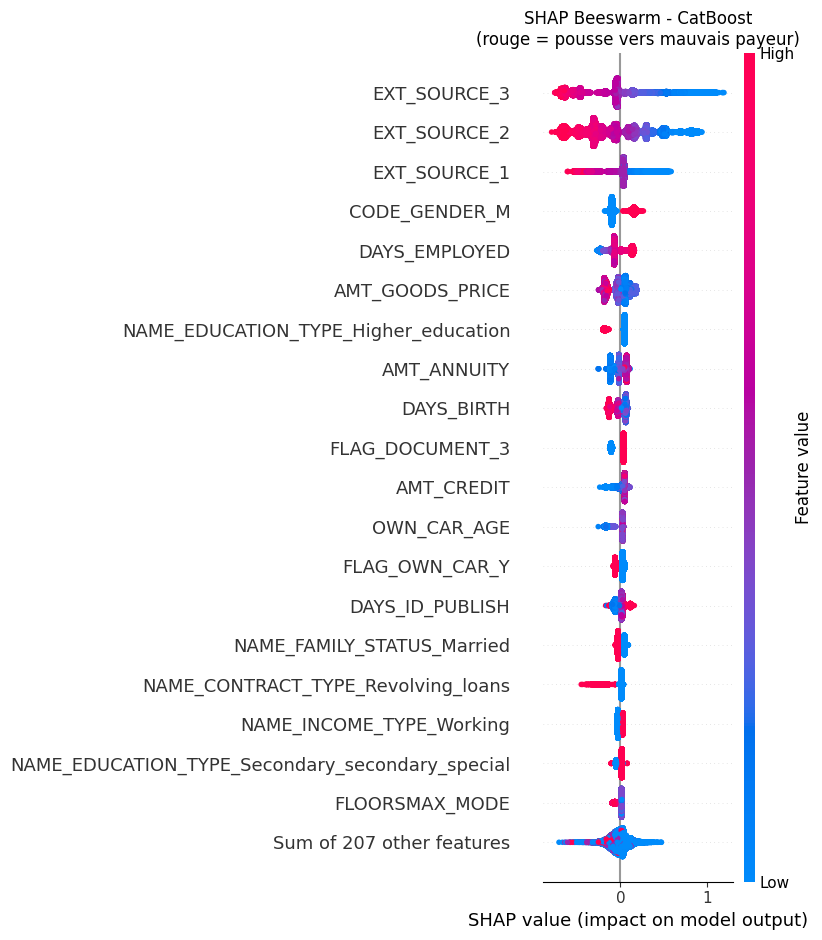

In [41]:
# quelles features pour "mauvais payeur" (valeur SHAP positive = risque +)

plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
plt.title("SHAP Beeswarm - CatBoost\n(rouge = pousse vers mauvais payeur)")
plt.tight_layout()
plt.show()


# WATERFALL — explication d'un individu précis

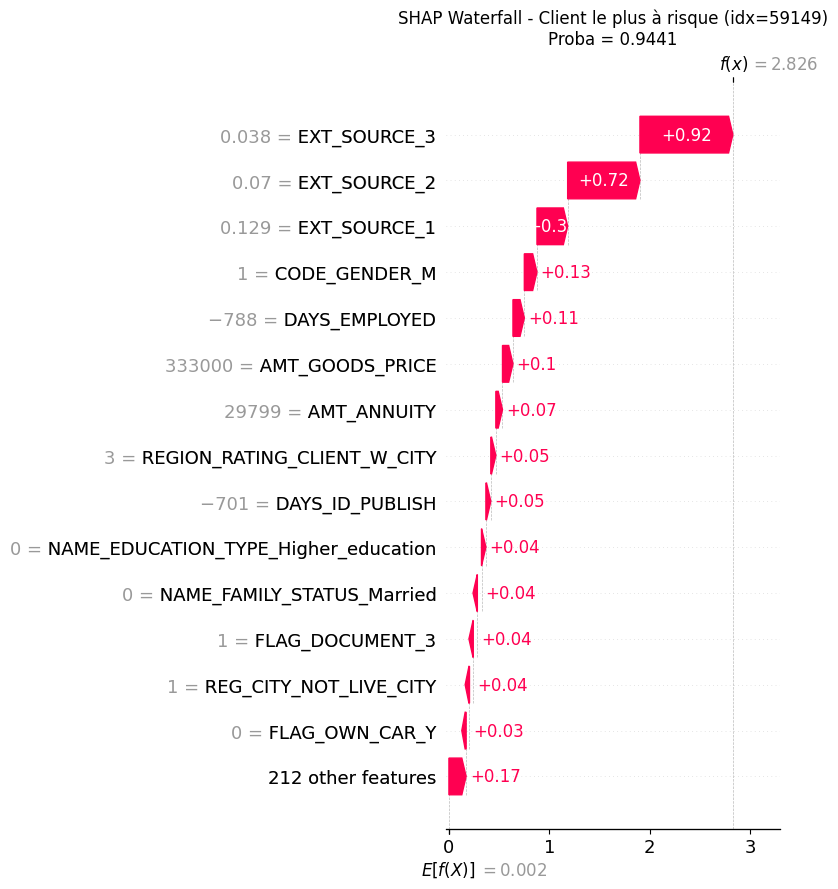

In [42]:
# Exemple : le client avec la proba la plus élevée (le plus à risque d'être mauvais payeur)

idx_most_risky = y_val_proba_cat.argmax()

plt.figure()
shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
plt.title(f"SHAP Waterfall - Client le plus à risque (idx={idx_most_risky})\nProba = {y_val_proba_cat[idx_most_risky]:.4f}")
plt.tight_layout()
plt.show()

# Waterfall sur un faux négatif (mauvais payeur non détecté: ce qui est le plus cher)

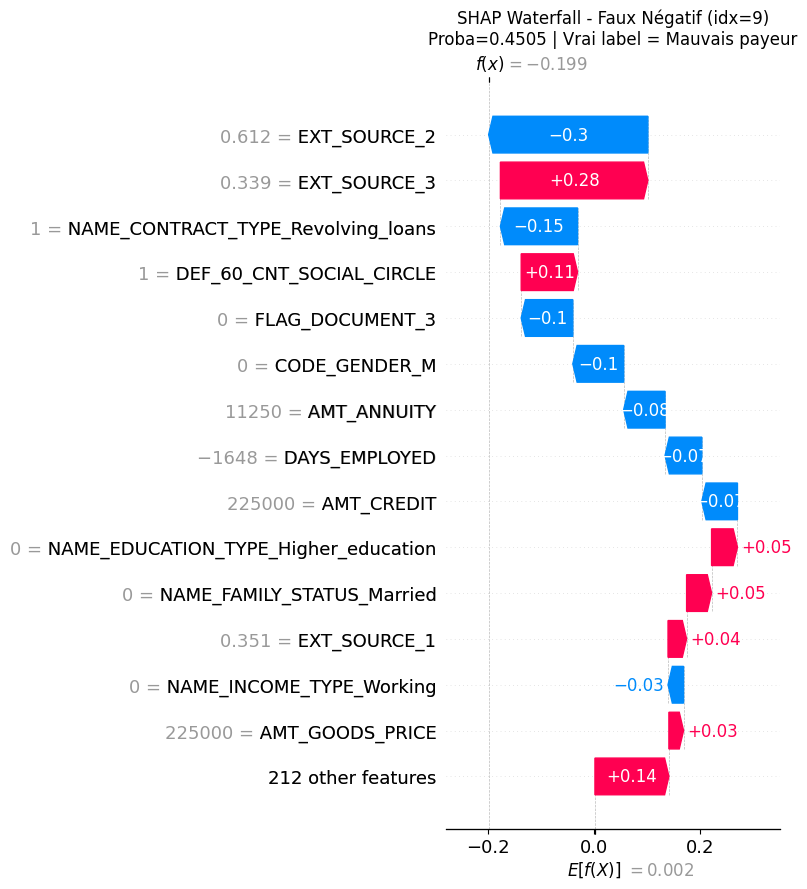

In [43]:
fn_indices = np.where((y_val == 1) & (y_val_pred_cat == 0))[0]
if len(fn_indices) > 0:
    idx_fn = fn_indices[0]
    plt.figure()
    shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Faux Négatif (idx={idx_fn})\nProba={y_val_proba_cat[idx_fn]:.4f} | Vrai label = Mauvais payeur")
    plt.tight_layout()
    plt.show()


# Log MLflow

In [44]:
with mlflow.start_run(run_name="CatBoost_SHAP_Analysis"):

    # Beeswarm
    fig_bee, _ = plt.subplots()
    shap.plots.beeswarm(shap_values, max_display=20, show=False)
    plt.title("SHAP Beeswarm - CatBoost")
    plt.tight_layout()
    mlflow.log_figure(fig_bee, "shap_beeswarm.png")

    # Waterfall client le plus risqué
    fig_wf, _ = plt.subplots()
    shap.plots.waterfall(shap_values[idx_most_risky], max_display=15, show=False)
    plt.title(f"SHAP Waterfall - Client le plus à risque")
    plt.tight_layout()
    mlflow.log_figure(fig_wf, "shap_waterfall_most_risky.png")

    # Waterfall faux négatif
    if len(fn_indices) > 0:
        fig_fn, _ = plt.subplots()
        shap.plots.waterfall(shap_values[idx_fn], max_display=15, show=False)
        plt.title(f"SHAP Waterfall - Faux Négatif")
        plt.tight_layout()
        mlflow.log_figure(fig_fn, "shap_waterfall_false_negative.png")